In [5]:
import cv2

In [15]:
import os
import json
import re
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_heights(folder_path):
    """
    Visualizes height data from JSON files in a folder.
    
    Args:
        folder_path (str): Path to the folder containing JSON files
    
    Creates two plots:
        1) Line graph of heights in frame number order
        2) Histogram of height distribution
    """
    # Get all JSON files in the folder
    json_files = list(Path(folder_path).glob("*.json"))
    
    if not json_files:
        print(f"No JSON files found in {folder_path}")
        return
    
    # Extract frame numbers and heights
    data = []
    for json_file in json_files:
        # Extract frame number from filename using regex
        # Pattern: *_<frame_number>_<date>_<time>.json
        match = re.search(r'_(\d+)_\d+_\d+\.json$', json_file.name)
        
        if match:
            frame_number = int(match.group(1))
            
            # Read JSON file and extract height
            try:
                with open(json_file, 'r') as f:
                    json_data = json.load(f)
                    
                    # Extract height from patient object
                    if 'patient' in json_data and 'height' in json_data['patient']:
                        height = json_data['patient']['height']
                        data.append((frame_number, height))
                    else:
                        print(f"Warning: 'patient.height' not found in {json_file.name}")
                        continue
                    
            except Exception as e:
                print(f"Error reading {json_file.name}: {e}")
                continue
    
    if not data:
        print("No valid height data found in JSON files")
        return
    
    # Sort by frame number
    data.sort(key=lambda x: x[0])
    
    frame_numbers = [d[0] for d in data]
    heights = [d[1] for d in data]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1) Line graph of heights in order
    ax1.plot(frame_numbers, heights, marker='o', linestyle='-', linewidth=2, markersize=4)
    ax1.set_xlabel('Frame Number', fontsize=12)
    ax1.set_ylabel('Height (mm)', fontsize=12)
    ax1.set_title('Height Over Frame Sequence', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 2) Histogram of heights
    ax2.hist(heights, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.set_xlabel('Height (mm)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Height Distribution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Total frames analyzed: {len(heights)}")
    print(f"Min height: {min(heights):.2f} mm")
    print(f"Max height: {max(heights):.2f} mm")
    print(f"Mean height: {sum(heights)/len(heights):.2f} mm")
    print(f"Std deviation: {(sum((h - sum(heights)/len(heights))**2 for h in heights) / len(heights))**0.5:.2f} mm")

In [16]:
FOLDER_PATH = "/home/gokul/defects/mr_8894/WorkflowCamera"

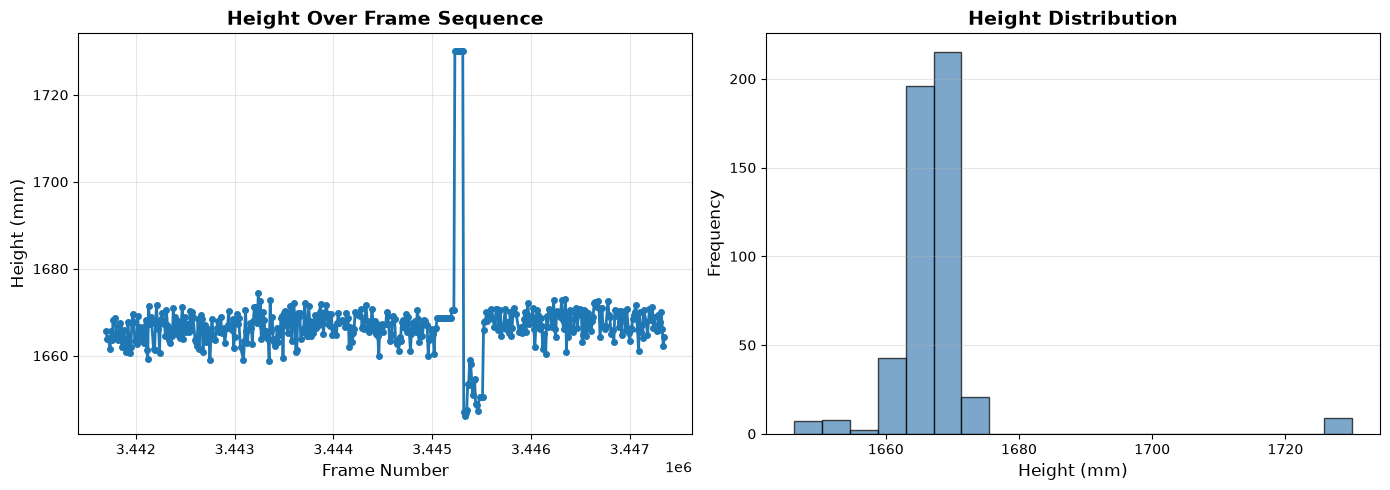


Summary Statistics:
Total frames analyzed: 501
Min height: 1646.22 mm
Max height: 1730.02 mm
Mean height: 1667.52 mm
Std deviation: 9.42 mm


In [17]:
visualize_heights(FOLDER_PATH)

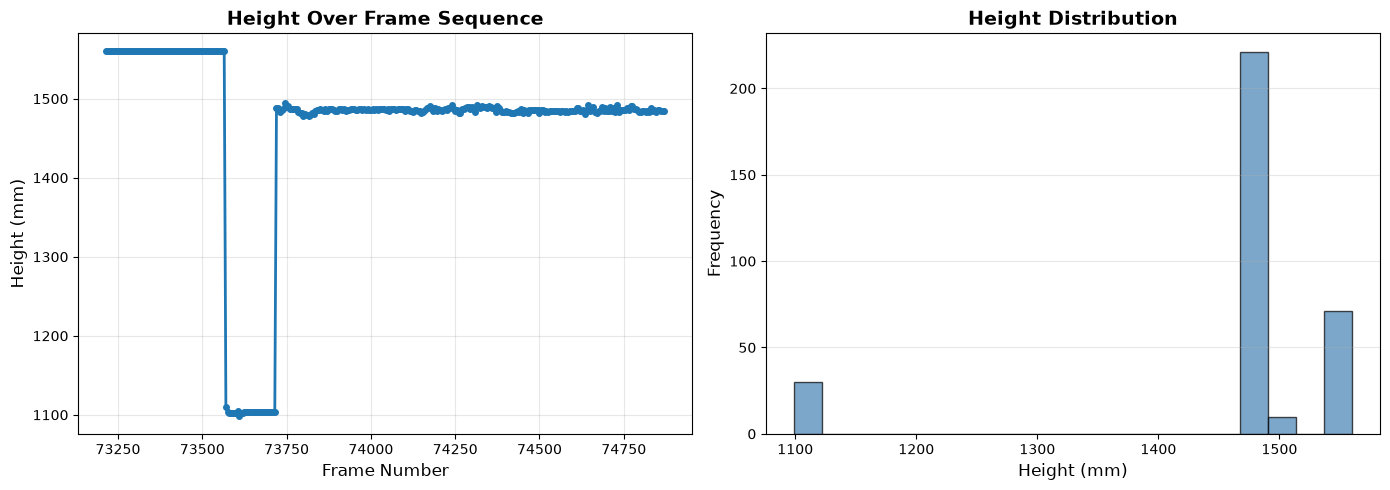


Summary Statistics:
Total frames analyzed: 332
Min height: 1098.99 mm
Max height: 1560.01 mm
Mean height: 1467.09 mm
Std deviation: 118.49 mm


In [19]:
FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
visualize_heights(FOLDER_PATH)

In [20]:
import os
import json
import re
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_weights(folder_path):
    """
    Visualizes weight data from JSON files in a folder.
    
    Args:
        folder_path (str): Path to the folder containing JSON files
    
    Creates two plots:
        1) Line graph of weights in frame number order
        2) Histogram of weight distribution
    """
    # Get all JSON files in the folder
    json_files = list(Path(folder_path).glob("*.json"))
    
    if not json_files:
        print(f"No JSON files found in {folder_path}")
        return
    
    # Extract frame numbers and weights
    data = []
    for json_file in json_files:
        # Extract frame number from filename using regex
        # Pattern: *_<frame_number>_<date>_<time>.json
        match = re.search(r'_(\d+)_\d+_\d+\.json$', json_file.name)
        
        if match:
            frame_number = int(match.group(1))
            
            # Read JSON file and extract weight
            try:
                with open(json_file, 'r') as f:
                    json_data = json.load(f)
                    
                    # Extract weight from patient object
                    if 'patient' in json_data and 'weight' in json_data['patient']:
                        weight = json_data['patient']['weight']
                        data.append((frame_number, weight))
                    else:
                        print(f"Warning: 'patient.weight' not found in {json_file.name}")
                        continue
                    
            except Exception as e:
                print(f"Error reading {json_file.name}: {e}")
                continue
    
    if not data:
        print("No valid weight data found in JSON files")
        return
    
    # Sort by frame number
    data.sort(key=lambda x: x[0])
    
    frame_numbers = [d[0] for d in data]
    weights = [d[1] for d in data]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1) Line graph of weights in order
    ax1.plot(frame_numbers, weights, marker='o', linestyle='-', linewidth=2, markersize=4)
    ax1.set_xlabel('Frame Number', fontsize=12)
    ax1.set_ylabel('weight (mm)', fontsize=12)
    ax1.set_title('weight Over Frame Sequence', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 2) Histogram of weights
    ax2.hist(weights, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.set_xlabel('weight (mm)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('weight Distribution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Total frames analyzed: {len(weights)}")
    print(f"Min weight: {min(weights):.2f} mm")
    print(f"Max weight: {max(weights):.2f} mm")
    print(f"Mean weight: {sum(weights)/len(weights):.2f} mm")
    print(f"Std deviation: {(sum((h - sum(weights)/len(weights))**2 for h in weights) / len(weights))**0.5:.2f} mm")

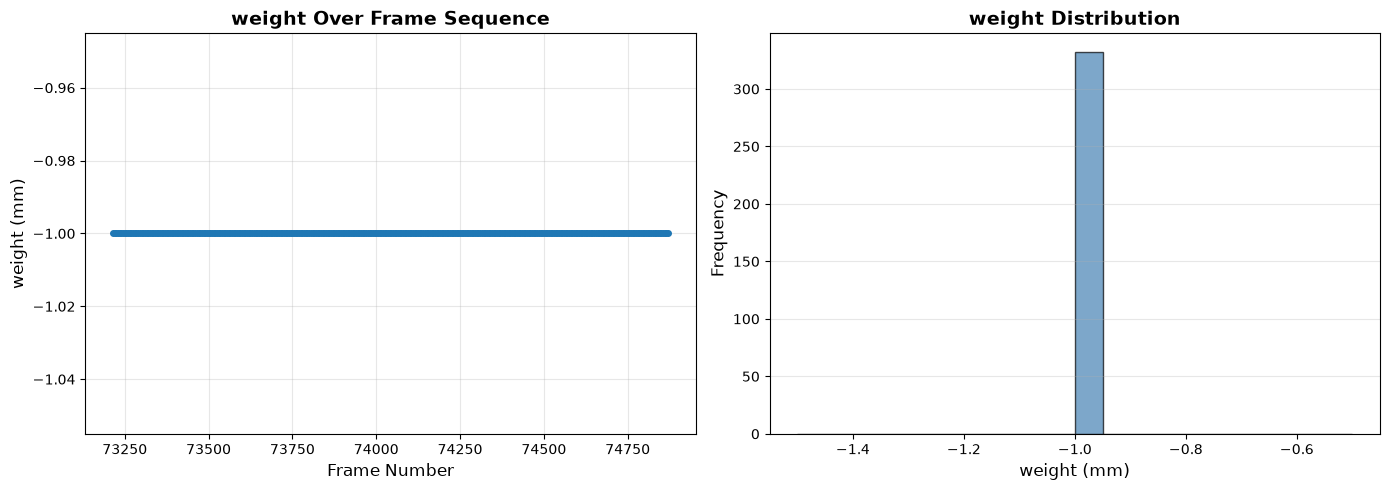


Summary Statistics:
Total frames analyzed: 332
Min weight: -1.00 mm
Max weight: -1.00 mm
Mean weight: -1.00 mm
Std deviation: 0.00 mm


In [21]:
FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
visualize_weights(FOLDER_PATH)